# GAN with Keras on MNIST

This notebook implements a Generative Adversarial Network (GAN) using TensorFlow/Keras to generate MNIST handwritten digit images.

Based on: https://colab.research.google.com/github/qaazii/3D-Bounding-Boxes-From-Monocular-Images/blob/master/Intro-to-Generative-Adversarial-Network/Tensorflow/GAN_Tensorflow_Fashion_MNIST.ipynb

In [1]:
!pip install numpy==1.19.2
!pip install tensorflow
!pip install torch==1.7.0
!pip install torchsummary==1.5.1
!pip install torchvision==0.8.1
!pip install matplotlib
!pip install ipython

  Using cached numpy-1.19.2.zip (7.3 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'


ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\1409A\anaconda3\envs\GenAiClass\Lib\site-packages\pip\_internal\cli\base_command.py", line 107, in _run_wrapper
    status = _inner_run()
  File "C:\Users\1409A\anaconda3\envs\GenAiClass\Lib\site-packages\pip\_internal\cli\base_command.py", line 98, in _inner_run
    return self.run(options, args)
           ~~~~~~~~^^^^^^^^^^^^^^^
  File "C:\Users\1409A\anaconda3\envs\GenAiClass\Lib\site-packages\pip\_internal\cli\req_command.py", line 96, in wrapper
    return func(self, options, args)
  File "C:\Users\1409A\anaconda3\envs\GenAiClass\Lib\site-packages\pip\_internal\commands\install.py", line 392, in run
    requirement_set = resolver.resolve(
        reqs, check_supported_wheels=not options.target_dir
    )
  File "C:\Users\1409A\anaconda3\envs\GenAiClass\Lib\site-packages\pip\_internal\resolution\resolvelib\resolver.py", line 99, in resolve
    result = self._result = resolver.resolve(
                            

ERROR: Could not find a version that satisfies the requirement torch==1.7.0 (from versions: 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0)
ERROR: No matching distribution found for torch==1.7.0


ERROR: Ignored the following yanked versions: 0.1.6, 0.1.7, 0.1.8, 0.1.9, 0.2.0, 0.2.1, 0.2.2, 0.2.2.post2, 0.2.2.post3
ERROR: Could not find a version that satisfies the requirement torchvision==0.8.1 (from versions: 0.21.0, 0.22.0, 0.22.1, 0.23.0, 0.24.0, 0.24.1, 0.25.0)
ERROR: No matching distribution found for torchvision==0.8.1


In [2]:
import os
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from IPython import display
import matplotlib.pyplot as plt
%matplotlib inline
from tensorflow import keras

In [3]:
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## Load and Preprocess Data

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype('float32')
x_train = (x_train - 127.5) / 127.5  # Normalize the images to [-1, 1]

# Batch and shuffle the data
BUFFER_SIZE = 60000
BATCH_SIZE = 128

train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

print('Training data shape:', x_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28, 1)


## Hyperparameters

In [5]:
latent_dim = 100
image_dim = 784  # 28 * 28
num_examples_to_generate = 25
learning_rate = 0.0002

# We will reuse this seed to visualize progress over training
seed = tf.random.normal([num_examples_to_generate, latent_dim])

## Generator Model

The generator takes a random noise vector (latent space) as input and produces a 28x28x1 image.

In [6]:
def build_generator(image_dim):
    inputs = keras.Input(shape=(100,), name='input_layer')
    x = layers.Dense(128, kernel_initializer=tf.keras.initializers.he_uniform(), name='dense_1')(inputs)
    x = layers.LeakyReLU(0.2, name='leaky_relu_1')(x)
    x = layers.Dense(256, kernel_initializer=tf.keras.initializers.he_uniform(), name='dense_2')(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=0.8, name='bn_1')(x)
    x = layers.LeakyReLU(0.2, name='leaky_relu_2')(x)
    x = layers.Dense(512, kernel_initializer=tf.keras.initializers.he_uniform(), name='dense_3')(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=0.8, name='bn_2')(x)
    x = layers.LeakyReLU(0.2, name='leaky_relu_3')(x)
    x = layers.Dense(1024, kernel_initializer=tf.keras.initializers.he_uniform(), name='dense_4')(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=0.8, name='bn_3')(x)
    x = layers.LeakyReLU(0.2, name='leaky_relu_4')(x)
    x = layers.Dense(image_dim, kernel_initializer=tf.keras.initializers.he_uniform(), activation='tanh', name='dense_5')(x)
    outputs = layers.Reshape((28, 28, 1), name='Reshape_Layer')(x)
    model = tf.keras.Model(inputs, outputs, name='Generator')
    return model

generator = build_generator(image_dim)
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_1 (LeakyReLU)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_2 (LeakyReLU)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_3 (LeakyReLU)        │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 1024)           │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_4 (LeakyReLU)        │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       803,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Reshape_Layer (Reshape)         │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,513,616 (5.77 MB)

 Trainable params: 1,510,032 (5.76 MB)

 Non-trainable params: 3,584 (14.00 KB)

## Discriminator Model

The discriminator takes a 28x28x1 image as input and outputs a probability indicating whether the image is real or fake.

In [7]:
def build_discriminator():
    inputs = keras.Input(shape=(28, 28, 1), name='input_layer')
    x = layers.Flatten(name='flatten_layer')(inputs)
    x = layers.Dense(512, kernel_initializer=tf.keras.initializers.he_uniform(), name='dense_1')(x)
    x = layers.LeakyReLU(0.2, name='leaky_relu_1')(x)
    x = layers.Dense(256, kernel_initializer=tf.keras.initializers.he_uniform(), name='dense_2')(x)
    x = layers.LeakyReLU(0.2, name='leaky_relu_2')(x)
    outputs = layers.Dense(1, kernel_initializer=tf.keras.initializers.he_uniform(), activation='sigmoid', name='dense_3')(x)
    model = tf.keras.Model(inputs, outputs, name='Discriminator')
    return model

discriminator = build_discriminator()
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_layer (Flatten)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_1 (LeakyReLU)        │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_2 (LeakyReLU)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

## Loss Functions

In [8]:
binary_cross_entropy = tf.keras.losses.BinaryCrossentropy()

def generator_loss(fake_output):
    return binary_cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = binary_cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = binary_cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

## Optimizers

In [9]:
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, beta_1=0.5, beta_2=0.999)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, beta_1=0.5, beta_2=0.999)

## Checkpoints

In [10]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, 'ckpt')
checkpoint = tf.train.Checkpoint(
    generator_optimizer=generator_optimizer,
    discriminator_optimizer=discriminator_optimizer,
    generator=generator,
    discriminator=discriminator
)

## Training Step

In [11]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_disc = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_gen, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_disc, discriminator.trainable_variables))

## Image Generation and Saving

In [12]:
os.makedirs('generated_images', exist_ok=True)

def generate_and_save_images(model, epoch, test_input):
    # training=False so all layers run in inference mode (batchnorm)
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(5, 5))
    for i in range(predictions.shape[0]):
        plt.subplot(5, 5, i + 1)
        pred = (predictions[i, :, :, 0] + 1) * 127.5
        pred = np.array(pred)
        plt.imshow(pred.astype(np.uint8), cmap='gray')
        plt.axis('off')

    plt.suptitle(f'Epoch {epoch}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'generated_images/image_at_epoch_{epoch:04d}.png')
    plt.show()

## Training Loop

In [13]:
def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()

        for image_batch in dataset:
            train_step(image_batch)

        display.clear_output(wait=True)
        generate_and_save_images(generator, epoch + 1, seed)

        # Save checkpoint every 15 epochs
        if (epoch + 1) % 15 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

        print(f'Time for epoch {epoch + 1} is {time.time() - start:.2f} sec')

    # Generate images after the final epoch
    display.clear_output(wait=True)
    generate_and_save_images(generator, epochs, seed)

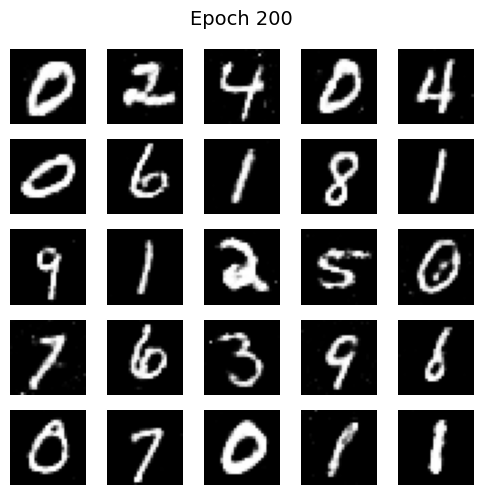

In [14]:
EPOCHS = 200
train(train_dataset, EPOCHS)